### 0. Preliminaries
Import necessary packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import kstwo

### 1. Manually Simulate with Given Data

The `riders.xlsx` and `drivers.xlsx` data sets are provided from the project assignment page. 

In [47]:
riders_df = pd.read_excel('riders.xlsx')
drivers_df = pd.read_excel('drivers.xlsx')

# Display head of the dataframes
display(drivers_df.head())
display(riders_df.head())

,id,arrival_time,offline_time,initial_location,current_location,status,arrival_datetime,offline_datetime
0,1,5.011975,11.638223,"(0.7897740952818868, 8.194226996886005)","(13.492895938215721, 17.375090044074234)",offline,2025-12-01 13:00:43.110,2025-12-01 19:38:17.601
1,2,5.557763,11.732854,"(4.600342938200451, 13.82151625336585)","(13.6809497478333, 15.070060581064372)",offline-scheduled,2025-12-01 13:33:27.947,2025-12-01 19:43:58.273
2,3,5.661047,12.723458,"(9.09829206926925, 11.669336718393772)","(15.86922281798255, 9.936190354974855)",offline-scheduled,2025-12-01 13:39:39.768,2025-12-01 20:43:24.450
3,4,5.757413,12.793147,"(14.723720219958555, 14.743429470057318)","(14.232702333916698, 12.939560071816741)",offline-scheduled,2025-12-01 13:45:26.686,2025-12-01 20:47:35.330
4,5,5.769205,12.431118,"(13.023825947458846, 12.501871643860605)","(19.845683334071563, 7.3885004325174215)",offline-scheduled,2025-12-01 13:46:09.139,2025-12-01 20:25:52.025


,id,request_time,pickup_time,dropoff_time,pickup_location,dropoff_location,status,request_datetime,pickup_datetime,dropoff_datetime
0,1,5.048803,5.372603,5.668817,"(8.52776815255513, 11.374422951736026)","(11.22406718305943, 18.28586415472845)",dropped-off,2025-12-01 13:02:55.690,2025-12-01 13:22:21.370,2025-12-01 13:40:07.743
1,2,5.113495,5.344117,5.658663,"(4.7260253234018075, 13.921168220313202)","(11.219433016467919, 9.224932723238288)",dropped-off,2025-12-01 13:06:48.580,2025-12-01 13:20:38.822,2025-12-01 13:39:31.187
2,3,5.114319,5.819045,6.154474,"(9.34931432850313, 14.855954034601385)","(15.818906976292498, 14.556629597532137)",dropped-off,2025-12-01 13:06:51.547,2025-12-01 13:49:08.563,2025-12-01 14:09:16.107
3,4,5.210384,5.492225,5.915581,"(5.341657715440439, 9.121586876730834)","(11.832789025965816, 11.90864135355879)",dropped-off,2025-12-01 13:12:37.383,2025-12-01 13:29:32.010,2025-12-01 13:54:56.092
4,5,5.229512,5.421566,6.019653,"(5.444067188695589, 13.774420071355813)","(11.208517457838962, 5.792638826367501)",dropped-off,2025-12-01 13:13:46.244,2025-12-01 13:25:17.639,2025-12-01 14:01:10.751


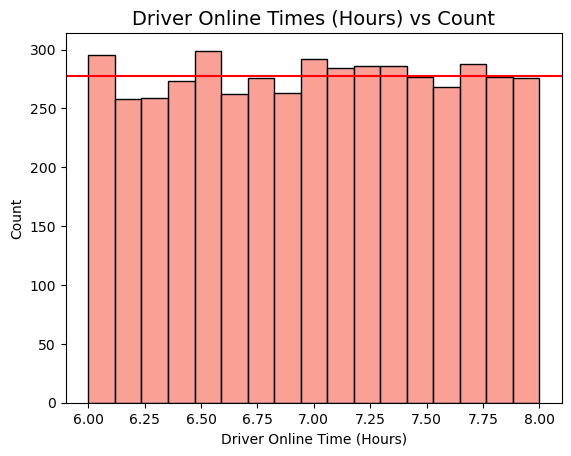

In [48]:
import seaborn as sns

# Extract driver arrival/offline times
driver_arrivals = drivers_df['arrival_time']
driver_offline = drivers_df['offline_time']

# Find and plot total driver work times
driver_work_times = driver_offline - driver_arrivals

sns.histplot(driver_work_times, color="salmon")
plt.title("Driver Online Times (Hours) vs Count", fontsize=14)
plt.xlabel("Driver Online Time (Hours)")

# Add horizontal line for expected number of counts in each bin
plt.axhline(y=len(driver_arrivals)/17, color="red")

In [49]:
from scipy.stats import chi2

def chi2_unif_test(data, lower, upper, bins):
    '''
    This function takes a vector, data, and computes the observed Chi-squared test statistic
    for the null hypothesis that these data are independtly distributed Uniform(lower, upper)
    random variables. 

    Inputs:
        data (vector) - A vector of observed data to calculate the test statistic on
        lower (real)  - A real number representing the lower bound for the uniform distribution
        upper (real)  - A real number representing the upper bound for the uniform distribution
        bins (int)    - The number of bins to split these data into

    Output:
        The observed Chi-squared test statistic that these data are independently distributed
        Uniform(lower, upper) random variables.
    '''

    # Number of observations in data
    n = len(data)

    # Define breakpoints used
    breakpoints = np.linspace(lower, upper, bins+1)

    # Expected number of observations in each bin
    expec_per_bin = np.repeat(n/bins, bins)

    # Number of observations in each bin
    obs_per_bin = []

    for i in range(bins):
        obs_per_bin.append(sum((breakpoints[i] < driver_work_times) & (driver_work_times <= breakpoints[i+1])))

    # Return observed test statistic
    return(sum((obs_per_bin - expec_per_bin)**2/expec_per_bin))

# Define parameter values for chi-squared test
bins = 17
lower = 6
upper = 8

# Calculate the observed chi-squared statistic
chi2_obs = chi2_unif_test(data=driver_work_times, lower=lower, upper=upper, bins=bins)

# Print results:
print("The observed test statistic is", round(chi2_obs, 2),"and the critical value for these parameter values and data are:", round(chi2.ppf(1-0.05, df=bins-1), 2))

The observed test statistic is 8.98 and the critical value for these parameter values and data are: 26.3


We conclude fail to reject the null hypothesis that these data are not Uniform(6,8) random variables.

### 2. Kolmogorov-Smirnov (KS) Test

In [259]:
def ks_test(data, func, lamb=1, plot=False):
    '''
    This function calculates the Kolmogorov-Smirnov test statistic for given data (assuming a true distribution that is exponential 
    with rate lambda). 

    Inputs:
        data (vector)   - The data vector of observed values
        func (function) - A python function that computes the exponential CDF for given data
        lamb (real)     - Rate parameter for exponential distribution
        plot (boolean)  - Should the data be plotted?

    Outputs:
        The observed test statistic for the KS test.
    '''

    # Convert the data to a numpy array
    data = np.array(data)

    # Convert data to standard uniform random variable
    U = np.sort(func(data, lamb))

    # Theoretical standard uniform CDF at the jump points
    U_cdf = np.linspace(0,1, len(U))
    
    # KS test statistic
    D = max(np.abs(U_cdf-U))

    # Return the test statistic and plotting vector if specified
    if plot==True:
        return D, U
    else:
        return D


def f_exp(x, lamb=1):
    ''' 
    Evaluate CDF at x for exponential random variable with rate parameter lamb

    Inputs:
        x (vector/real) - The data at which to compute the CDF.
        lamb (real)     - The rate parameter.  

    Outputs:
        Value of the exponential CDF at x (with rate parameter lamb).
    '''
    return 1-np.exp(-lamb*x)


# Find the driver inter-arrival times
driver_arrival_intervals = np.array(driver_arrivals[1:]) - np.array(driver_arrivals[0:-1])

# Calculate the KS test statistic for the driver inter-arrival times
ks_obs = ks_test(data=driver_arrival_intervals, func=f_exp, lamb=4.75)

# Compare to theoretical quantile values
critical_val = kstwo.isf(0.05, len(driver_arrival_intervals))
print("The observed test statistic is", round(ks_obs, 4),"and the critical value for these parameter values and data are:", round(critical_val, 4))

The observed test statistic is 0.0108 and the critical value for these parameter values and data are: 0.0197


Hence, since $D_n < d_{n,1-\alpha}$ we fail to reject the null that the driver inter-arrival times are distributed as Exp(4.75) random variables.

### 3. Driver Arrivals

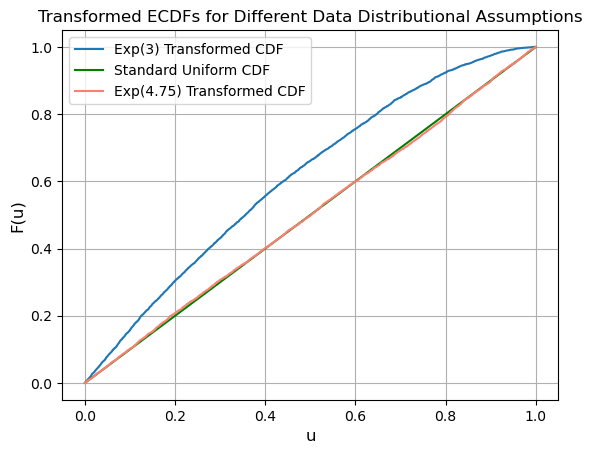

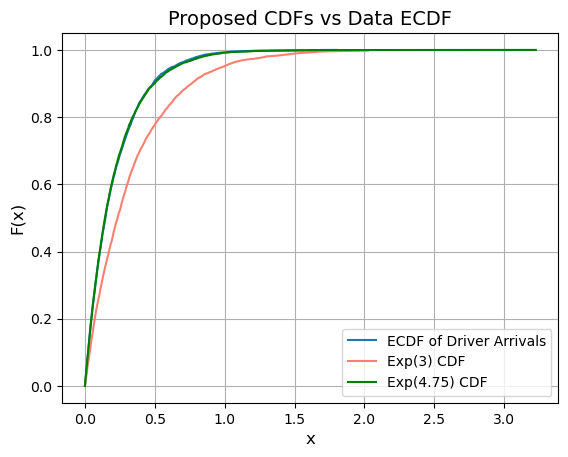

In [ ]:
# Transformed data assuming these data are exp(3) and exp(4.75) random variables respectively
_, ECDF_trans_3 = ks_test(data=driver_arrival_intervals, func=f_exp, lamb=3, plot=True)
_, ECDF_trans_fitted = ks_test(data=driver_arrival_intervals, func=f_exp, lamb=4.75, plot=True)

# Plot the ECDF of the transformed CDFs for exp(3) and exp(4.75) r.v.s with the standard uniform CDF
plt.plot(ECDF_trans_3, np.linspace(0,1,len(ECDF_trans_3)), label="Exp(3) Transformed CDF")
plt.plot(np.linspace(0,1,len(ECDF_trans_3)), np.linspace(0,1,len(ECDF_trans_3)), label="Standard Uniform CDF", color="green")
plt.plot(ECDF_trans_fitted, np.linspace(0,1,len(ECDF_trans_fitted)), label="Exp(4.75) Transformed CDF", color="salmon")
plt.legend()
plt.title("Transformed ECDFs for Different Data Distributional Assumptions")
plt.ylabel("F(u)", fontsize=12)
plt.xlabel("u", fontsize=12)
plt.grid()
plt.show()

# Generate 5000 Exp(3) random variables and 5000 Exp(4.75) random variables
n = 5000
exp3 = []
exp_custom = []

for i in range(n):
    exp3.append(random.expovariate(3))
    exp_custom.append(random.expovariate(4.75))


# Calculate the ECDF for the driver inter-arrival times
ECDF = np.sort(driver_arrival_intervals)

# Plot the ECDF for the driver inter-arrival times and the proposed distributions for these data
plt.plot(ECDF, np.linspace(0,1,len(ECDF)), label="ECDF of Driver Arrivals")
plt.plot(np.sort(exp3)[:4990], np.linspace(0,1,n)[:4990], label="Exp(3) CDF", color="salmon")
plt.plot(np.sort(exp_custom), np.linspace(0,1,n), label="Exp(4.75) CDF", color="green")
plt.legend()
plt.ylabel("F(x)", fontsize=12)
plt.xlabel("x", fontsize=12)
plt.title("Proposed CDFs vs Data ECDF", fontsize=14)
plt.grid()
plt.show()

### 4. Rider Arrivals

In [273]:
# Extract rider request times
rider_requests = riders_df['request_time']

# Create rider inter-request times
rider_request_intervals = np.array(rider_requests[1:]) - np.array(rider_requests[0:-1])

# Calculate the observed KS statistic for the proposed distribution of these data
ks_obs = ks_test(data=rider_request_intervals, func=f_exp, lamb=35)

# Calculate the corresponding KS quantile value
critical_val = kstwo.isf(0.05, len(driver_arrival_intervals))
print("The observed test statistic is", round(ks_obs, 4),"and the critical value for these parameter values and data are:", round(critical_val, 4))

The observed test statistic is 0.0064 and the critical value for these parameter values and data are: 0.0197


Hence, since $D_n < d_{n,1-\alpha}$ we fail to reject the null that the rider inter-request times are distributed as Exp(35) random variables.

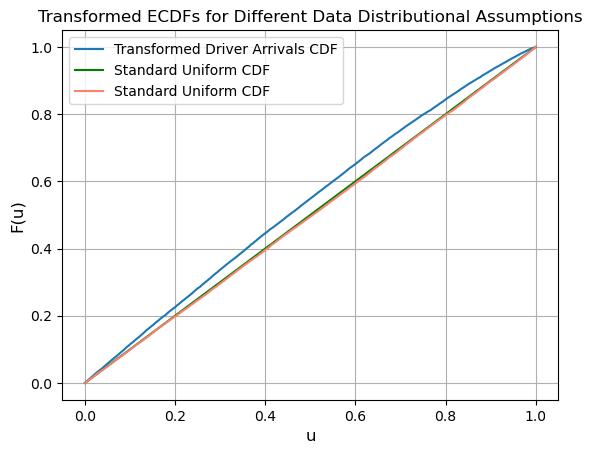

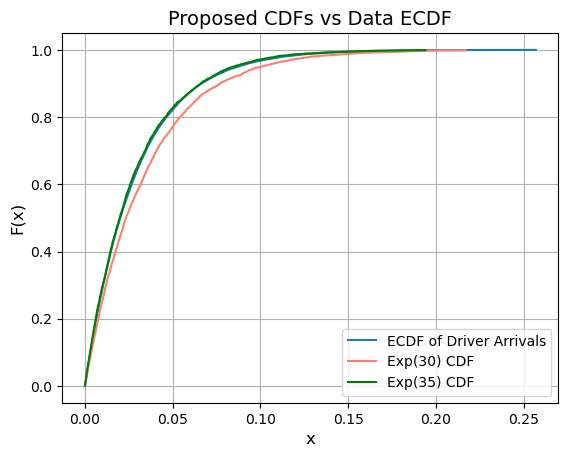

In [277]:
# Transformed data assuming these data are exp(30) and exp(35) random variables respectively
_, ECDF_trans_30 = ks_test(data=rider_request_intervals, func=f_exp, lamb=30, plot=True)
_, ECDF_trans_35 = ks_test(data=rider_request_intervals, func=f_exp, lamb=35, plot=True)

# Plot the ECDF of the transformed CDFs for exp(30) and exp(35) r.v.s with the standard uniform CDF
plt.plot(ECDF_trans_30, np.linspace(0,1,len(ECDF_trans_30)), label="Transformed Driver Arrivals CDF")
plt.plot(np.linspace(0,1,len(ECDF_trans_30)), np.linspace(0,1,len(ECDF_trans_30)), label="Standard Uniform CDF", color="green")
plt.plot(ECDF_trans_35, np.linspace(0,1,len(ECDF_trans_35)), label="Standard Uniform CDF", color="salmon")
plt.legend()
plt.grid()
plt.title("Transformed ECDFs for Different Data Distributional Assumptions")
plt.ylabel("F(u)", fontsize=12)
plt.xlabel("u", fontsize=12)
plt.show()

# Generate 5000 Exp(30) random variables and 5000 Exp(35) random variables
n = 5000
exp30 = []
exp35 = []

for i in range(n):
    exp30.append(random.expovariate(30))
    exp35.append(random.expovariate(35))

# Calculate the ECDF for the rider inter-request times
ECDF = np.sort(rider_request_intervals)

# Plot the ECDF for the rider inter-request times and the proposed distributions for these data
plt.plot(ECDF, np.linspace(0,1,len(ECDF)), label="ECDF of Driver Arrivals")
plt.plot(np.sort(exp30)[:4995], np.linspace(0,1,n)[:4995], label="Exp(30) CDF", color="salmon")
plt.plot(np.sort(exp35)[:4997], np.linspace(0,1,n)[:4997], label="Exp(35) CDF", color="green")
plt.legend()
plt.grid()
plt.ylabel("F(x)", fontsize=12)
plt.xlabel("x", fontsize=12)
plt.title("Proposed CDFs vs Data ECDF", fontsize=14)
plt.show()

### 5. Rider Location

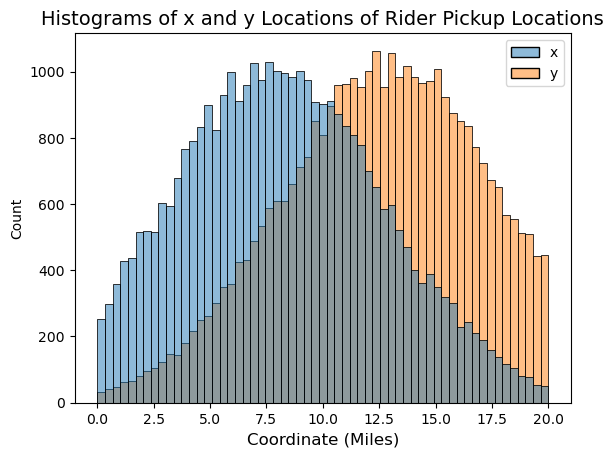

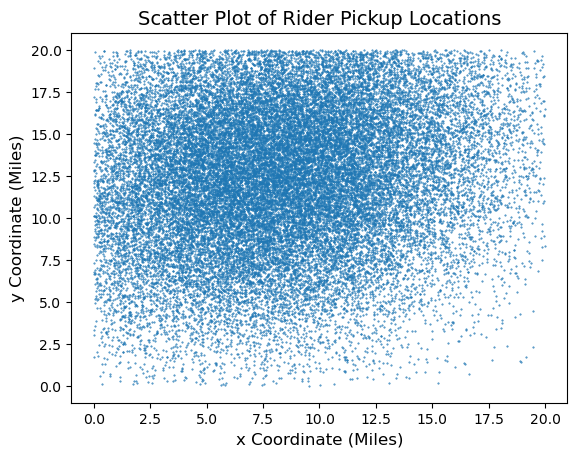

In [293]:
import ast
from collections import Counter

# Extract driver arrival/offline times
rider_ploc = riders_df['pickup_location']
rider_ploc = np.array([ast.literal_eval(s) for s in rider_ploc])

rider_df = pd.DataFrame(rider_ploc, columns=["x", "y"])
sns.histplot(rider_df)
plt.title("Histograms of x and y Locations of Rider Pickup Locations", fontsize=14)
plt.xlabel("Coordinate (Miles)", fontsize=12)
plt.show()

plt.scatter(rider_ploc[:,0], rider_ploc[:,1], s=0.2)
plt.title("Scatter Plot of Rider Pickup Locations", fontsize=14)
plt.xlabel("x Coordinate (Miles)", fontsize=12)
plt.ylabel("y Coordinate (Miles)", fontsize=12)
plt.show()

In [294]:
# Serial Test
k=4
d=2

breakpoints = np.linspace(0, 1, k)

bins = []

rider_ploc = rider_ploc/20

for l in range(len(rider_ploc)):
    for i in range(k-1):
        for j in range(k-1):
            if (breakpoints[i] < (rider_ploc[l])[0]) & ((rider_ploc[l])[0] < breakpoints[i+1]):
                if (breakpoints[j] < (rider_ploc[l])[1]) & ((rider_ploc[l])[1] < breakpoints[j+1]):
                    bins.append(j*(k-1) + i + 1)


bins_counter = Counter(np.sort(bins))

test_stat = 0
expec_count = len(rider_ploc)/9
for i in range((k-1)**2):
    test_stat += (bins_counter[i] - expec_count)**2/expec_count

test_stat


20304.708579065107